  checking_account  duration credit_history purpose  credit_amount savings  \
0              A11         6            A34     A43           1169     A65   
1              A12        48            A32     A43           5951     A61   
2              A14        12            A34     A46           2096     A61   
3              A11        42            A32     A42           7882     A61   
4              A11        24            A33     A40           4870     A61   

  employment  installment_rate personal_status other_debtors  ...  property  \
0        A75                 4             A93          A101  ...      A121   
1        A73                 2             A92          A101  ...      A121   
2        A74                 2             A93          A101  ...      A121   
3        A74                 2             A93          A103  ...      A122   
4        A73                 3             A93          A101  ...      A124   

  age  other_installment_plans housing existing_credits 

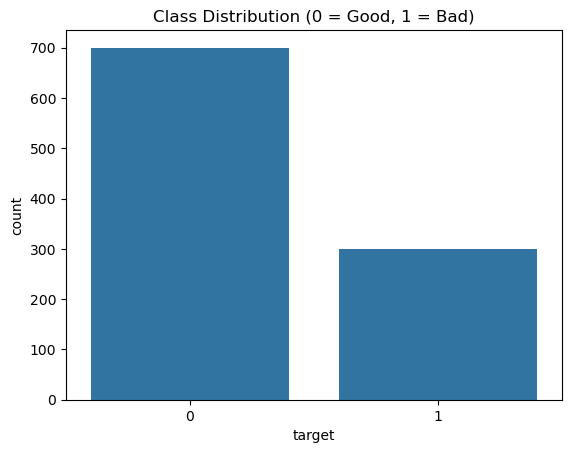


--- MODEL EVALUATION ---
Accuracy: 0.8
Precision: 0.6938775510204082
Recall: 0.576271186440678
F1 Score: 0.6296296296296297


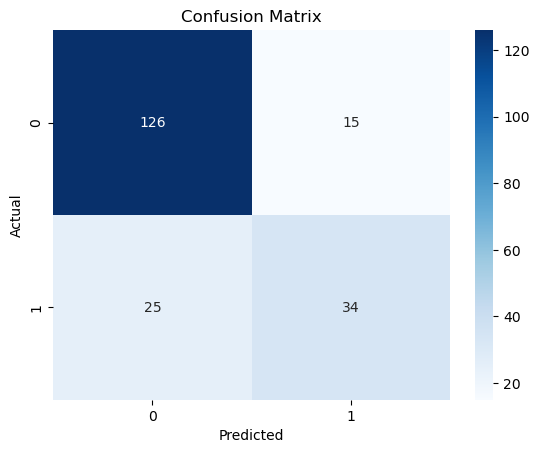

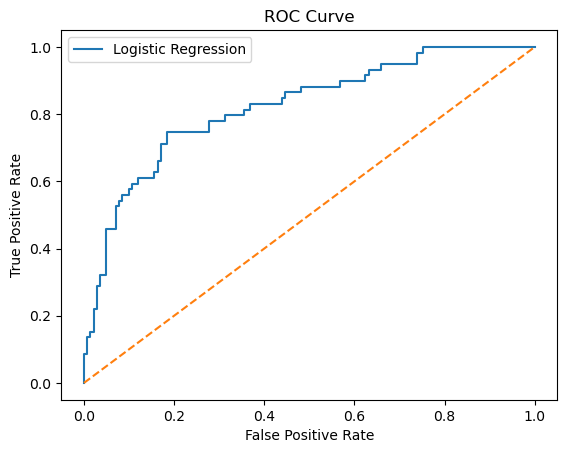

ROC-AUC Score: 0.8219737949272748
Total Misclassification Cost: 140


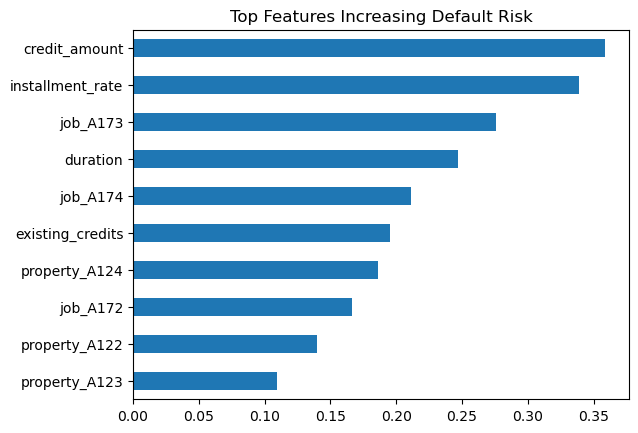

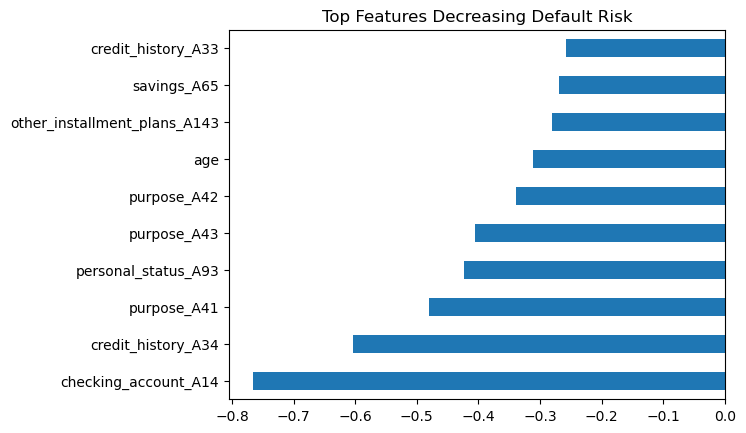


--- CUSTOM THRESHOLD (0.3) ---
Accuracy: 0.735
Recall: 0.7796610169491526


In [2]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

# ================================
# 2. LOAD DATASET
# ================================

# Column names based on dataset description
column_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings", "employment", "installment_rate",
    "personal_status", "other_debtors", "residence_since",
    "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "dependents", "telephone",
    "foreign_worker", "target"
]

# Load dataset (make sure german.data is in same folder)
#df = pd.read_csv("german.data", sep=" ", header=None, names=column_names)
df = pd.read_csv("german.data", sep="\s+", header=None, names=column_names)

#Optional Check for null values in dataset
#print(df.isnull().sum())

# ================================
# 3. DATA UNDERSTANDING
# ================================

# print("First 5 rows:")
print(df.head())

# print("\nDataset Info:")
print(df.info())

# print("\nClass Distribution:")
print(df['target'].value_counts())

# ================================
# 4. TARGET TRANSFORMATION
# ================================

# Convert target:
# 1 (Good) -> 0
# 2 (Bad)  -> 1 (default)
df['target'] = df['target'].map({1: 0, 2: 1})

# ================================
# 5. EXPLORATORY DATA ANALYSIS
# ================================

sns.countplot(x='target', data=df)
plt.title("Class Distribution (0 = Good, 1 = Bad)")
plt.show()

# ================================
# 6. PREPROCESSING
# ================================

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Convert categorical variables to numerical (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# ================================
# 7. TRAIN-TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 8. FEATURE SCALING
# ================================

# Important for Logistic Regression
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 9. LOGISTIC REGRESSION MODEL (WITH REGULARIZATION)
# ================================

# L2 Regularization (Ridge)
# C controls regularization strength (lower = stronger regularization)
model = LogisticRegression(penalty='l2', C=0.5, max_iter=1000)

# Train model
model.fit(X_train, y_train)


# ================================
# 10. PREDICTIONS
# ================================

# Predicted classes
y_pred = model.predict(X_test)

# Predicted probabilities (for ROC, threshold tuning)
y_prob = model.predict_proba(X_test)[:, 1]

# ================================
# 11. EVALUATION METRICS
# ================================

print("\n--- MODEL EVALUATION ---")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision
print("Precision:", precision_score(y_test, y_pred))

# Recall
print("Recall:", recall_score(y_test, y_pred))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred))

# ================================
# 12. CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 13. ROC CURVE + AUC
# ================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ================================
# 14. COST-SENSITIVE EVALUATION (ADVANCED)
# ================================

# According to dataset:
# Misclassifying BAD as GOOD = cost 5
# Misclassifying GOOD as BAD = cost 1

cost = 0

for actual, pred in zip(y_test, y_pred):
    if actual == 1 and pred == 0:  # Bad predicted as Good
        cost += 5
    elif actual == 0 and pred == 1:  # Good predicted as Bad
        cost += 1

print("Total Misclassification Cost:", cost)

# ================================
# 15. FEATURE IMPORTANCE (INTERPRETATION)
# ================================

# Get feature importance (coefficients)
importance = pd.Series(model.coef_[0], index=X.columns)

# Plot top features
importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Features Increasing Default Risk")
plt.show()

importance.sort_values().head(10).plot(kind='barh')
plt.title("Top Features Decreasing Default Risk")
plt.show()

# ================================
# 16. OPTIONAL: THRESHOLD TUNING (ADVANCED)
# ================================

# Change decision threshold from 0.5 to 0.3
y_pred_custom = (y_prob > 0.3).astype(int)

print("\n--- CUSTOM THRESHOLD (0.3) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))